# Customer Segmentation using K-Means Clustering

## Objective
Segment customers based on purchasing behavior using RFM (Recency, Frequency, Monetary) features and K-Means clustering.

## Dataset
- Source: rfm_features.csv
- Customers: 5878

## Features Used
- Recency
- Frequency
- Monetary

## Methodology
1. Load RFM dataset
2. Select RFM features
3. Standardize features using StandardScaler
4. Determine optimal K using Elbow Method
5. Train K-Means clustering model
6. Analyze and label customer segments
7. Export results to customer_segments.csv

## Final Segments
- Champions
- Loyal Customers
- Potential Loyalists
- Lost Customers

## Load and Explore the Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

rfm = pd.read_csv("../data/rfm_features.csv")

print("Shape:", rfm.shape)

print("\nColumns:")
print(rfm.columns.tolist())

rfm.head()

Shape: (5878, 12)

Columns:
['CustomerID', 'Recency', 'Frequency', 'Monetary', 'F_Score', 'R_Score', 'M_Score', 'RFM_Score', 'Segment', 'Churned_x', 'Churned_y', 'Churned']


,CustomerID,Recency,Frequency,Monetary,F_Score,R_Score,M_Score,RFM_Score,Segment,Churned_x,Churned_y,Churned
0,12346,326,12,77556.46,5,2,5,4.000000,Loyal Customers,1,1,1
1,12347,2,8,4921.53,4,5,5,4.666667,Champions,0,0,0
2,12348,75,5,2019.40,4,3,4,3.666667,Potential Loyalists,0,0,0
3,12349,19,4,4428.69,3,5,5,4.333333,Loyal Customers,0,0,0
4,12350,310,1,334.40,1,2,2,1.666667,Lost,1,1,1


## Select RFM Features

In [3]:
features = rfm[['Recency', 'Frequency', 'Monetary']]

print(features.head())

   Recency  Frequency  Monetary
0      326         12  77556.46
1        2          8   4921.53
2       75          5   2019.40
3       19          4   4428.69
4      310          1    334.40


## Scale Features Using StandardScaler

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(features)

print(X[:5])

[[ 0.59558355  0.43899789  5.16637792]
 [-0.95227909  0.13150188  0.13612722]
 [-0.60353226 -0.09912012 -0.06485654]
 [-0.87106408 -0.17599412  0.10199614]
 [ 0.51914589 -0.40661612 -0.18154933]]


## Determine Optimal Number of Clusters

In [5]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X)

    inertia.append(model.inertia_)

## Visualize the Elbow Method

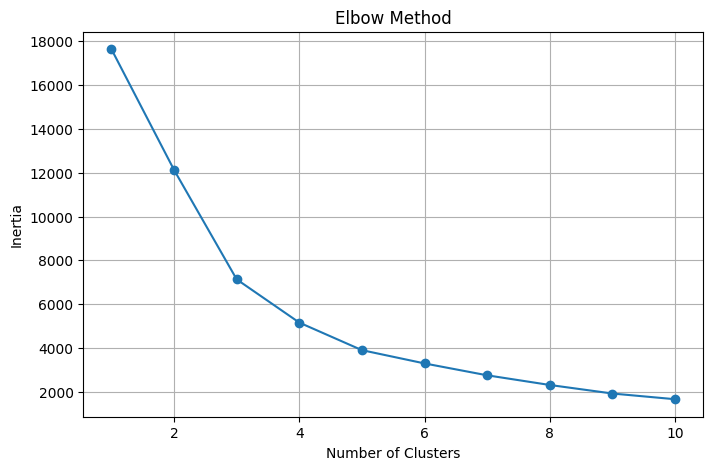

In [6]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.grid(True)

plt.show()

## Apply K-Means Clustering

In [7]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(X)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,F_Score,R_Score,M_Score,RFM_Score,Segment,Churned_x,Churned_y,Churned,Cluster
0,12346,326,12,77556.46,5,2,5,4.000000,Loyal Customers,1,1,1,0
1,12347,2,8,4921.53,4,5,5,4.666667,Champions,0,0,0,0
2,12348,75,5,2019.40,4,3,4,3.666667,Potential Loyalists,0,0,0,0
3,12349,19,4,4428.69,3,5,5,4.333333,Loyal Customers,0,0,0,0
4,12350,310,1,334.40,1,2,2,1.666667,Lost,1,1,1,1


## Save the Trained K-Means Model

In [19]:
import joblib

joblib.dump(kmeans, "../models/customer_segmentation_model.pkl")

print("Model saved successfully!")

Model saved successfully!


## Save the StandardScaler

In [20]:
joblib.dump(scaler, "../models/customer_segmentation_scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!


## Analyze Cluster Characteristics

In [9]:
cluster_summary = rfm.groupby('Cluster')[
    ['Recency', 'Frequency', 'Monetary']
].mean()

print(cluster_summary)

            Recency   Frequency       Monetary
Cluster                                       
0         67.054455    7.267848    2921.080058
1        463.032032    2.212212     748.536998
2          3.500000  212.500000  428611.997500
3         24.263158  100.131579   77728.265579


## Assign Business Segment Labels

In [10]:
cluster_names = {
    0: "Potential Loyalists",
    1: "Lost Customers",
    2: "Champions",
    3: "Loyal Customers"
}

rfm['Customer_Segment'] = rfm['Cluster'].map(cluster_names)

rfm[['CustomerID', 'Cluster', 'Customer_Segment']].head()

,CustomerID,Cluster,Customer_Segment
0,12346,0,Potential Loyalists
1,12347,0,Potential Loyalists
2,12348,0,Potential Loyalists
3,12349,0,Potential Loyalists
4,12350,1,Lost Customers


## Analyze Segment Distribution

In [11]:
segment_counts = rfm['Customer_Segment'].value_counts()

print(segment_counts)

Customer_Segment
Potential Loyalists    3838
Lost Customers         1998
Loyal Customers          38
Champions                 4
Name: count, dtype: int64


## Visualize Customer Segment Distribution

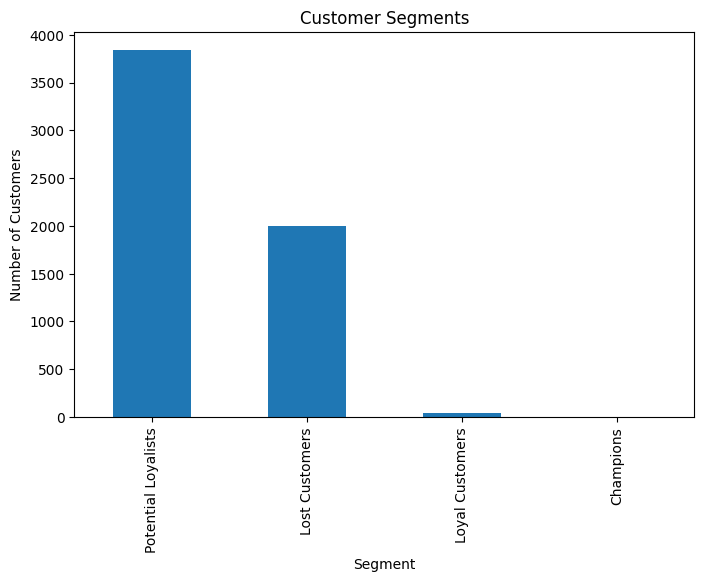

In [12]:
plt.figure(figsize=(8,5))

segment_counts.plot(kind='bar')

plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.show()

## Export Segmentation Results

In [13]:
rfm.to_csv(
    "../data/customer_segments.csv",
    index=False
)

print("Customer Segments Exported Successfully!")

Customer Segments Exported Successfully!


## Visualize Customer Clusters - Scatter Plot

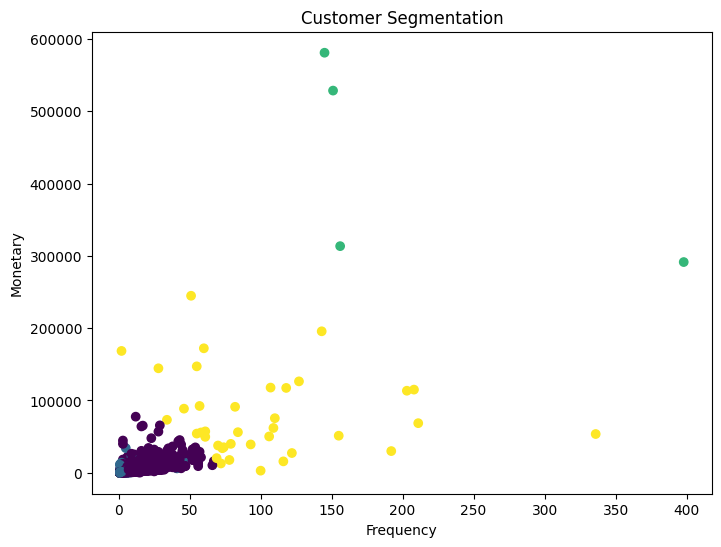

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(
    rfm['Frequency'],
    rfm['Monetary'],
    c=rfm['Cluster']
)

plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.title("Customer Segmentation")

plt.show()

## Visualize Segment Composition - Pie Chart

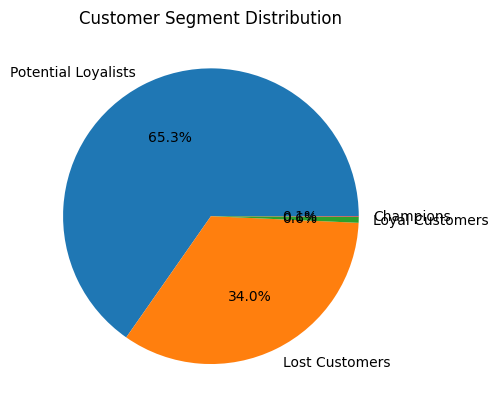

In [15]:
segment_counts.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel("")
plt.title("Customer Segment Distribution")

plt.show()